# Extracción de canales de color y guardado por separado 

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

Definir carpetas

In [8]:
# Rutas de carpetas
carpeta_imagenes = '/Users/silviamendez/Desktop/Servicio Social/Tareas pdf/Imagenes'
carpeta_salida = '/Users/silviamendez/Desktop/Servicio Social/Salida canales'

# Crear carpeta principal de salida
if not os.path.exists(carpeta_salida): #Verifica si la carpeta de salida no existe
    os.makedirs(carpeta_salida) # Si no existe, la crea automáticamente 

# Crear subcarpetas
carpeta_comparativas = os.path.join(carpeta_salida, 'comparativas') #Ruta para imagenes comparativas
carpeta_gris = os.path.join(carpeta_salida, 'gris') #Ruta para canal gris
carpeta_azul = os.path.join(carpeta_salida, 'azul') #Ruta para canal azul
carpeta_verde = os.path.join(carpeta_salida, 'verde') #Ruta para canal verde
carpeta_rojo = os.path.join(carpeta_salida, 'rojo') #Ruta para canal rojo

#Recorrer todas las carpetas que se acaban de definir 
for carpeta in [carpeta_comparativas, carpeta_gris, carpeta_azul, carpeta_verde, carpeta_rojo]:
    if not os.path.exists(carpeta): #Verifica que cada subcarpeta no exista 
        os.makedirs(carpeta) # Si no existe, la crea

print('Carpeta de entrada:', carpeta_imagenes) #Imprimir ruta de entrada 
print('Carpeta de salida:', carpeta_salida) #Imprimir ruta de salida 

Carpeta de entrada: /Users/silviamendez/Desktop/Servicio Social/Tareas pdf/Imagenes
Carpeta de salida: /Users/silviamendez/Desktop/Servicio Social/Salida canales


Procesar imágenes

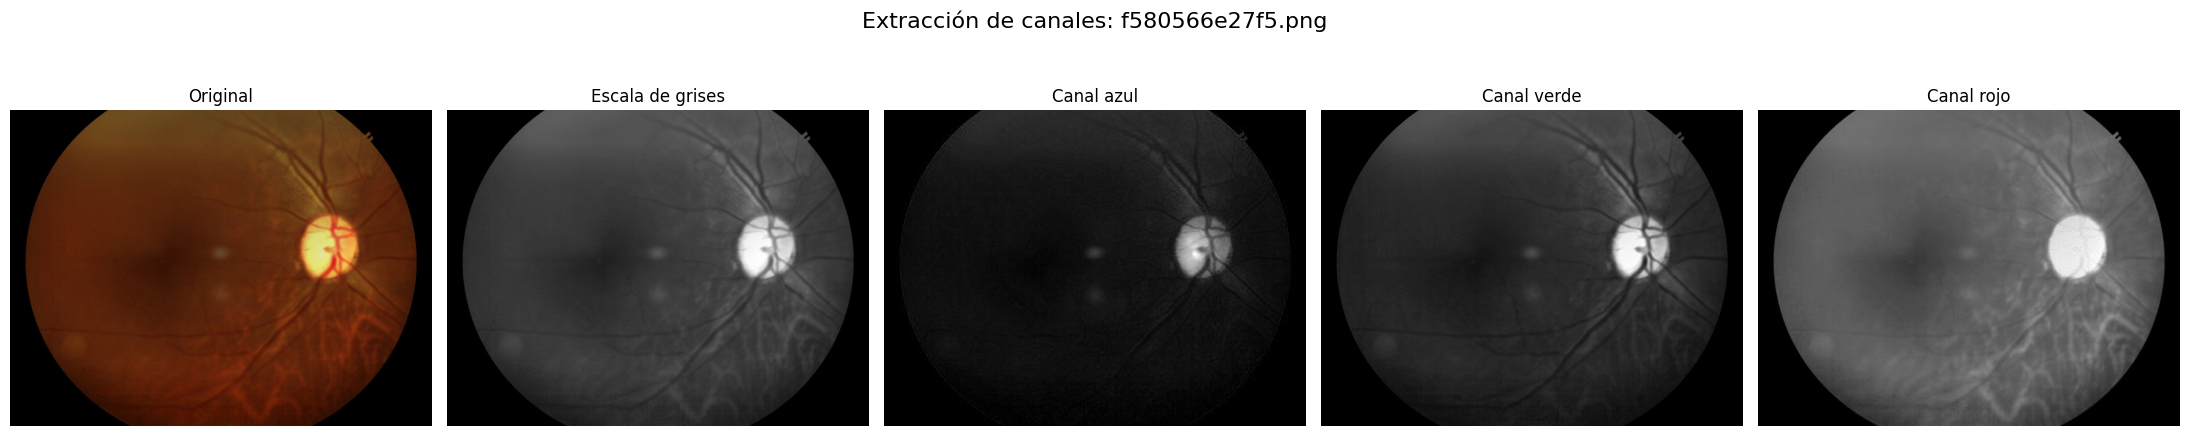

Procesada: f580566e27f5.png


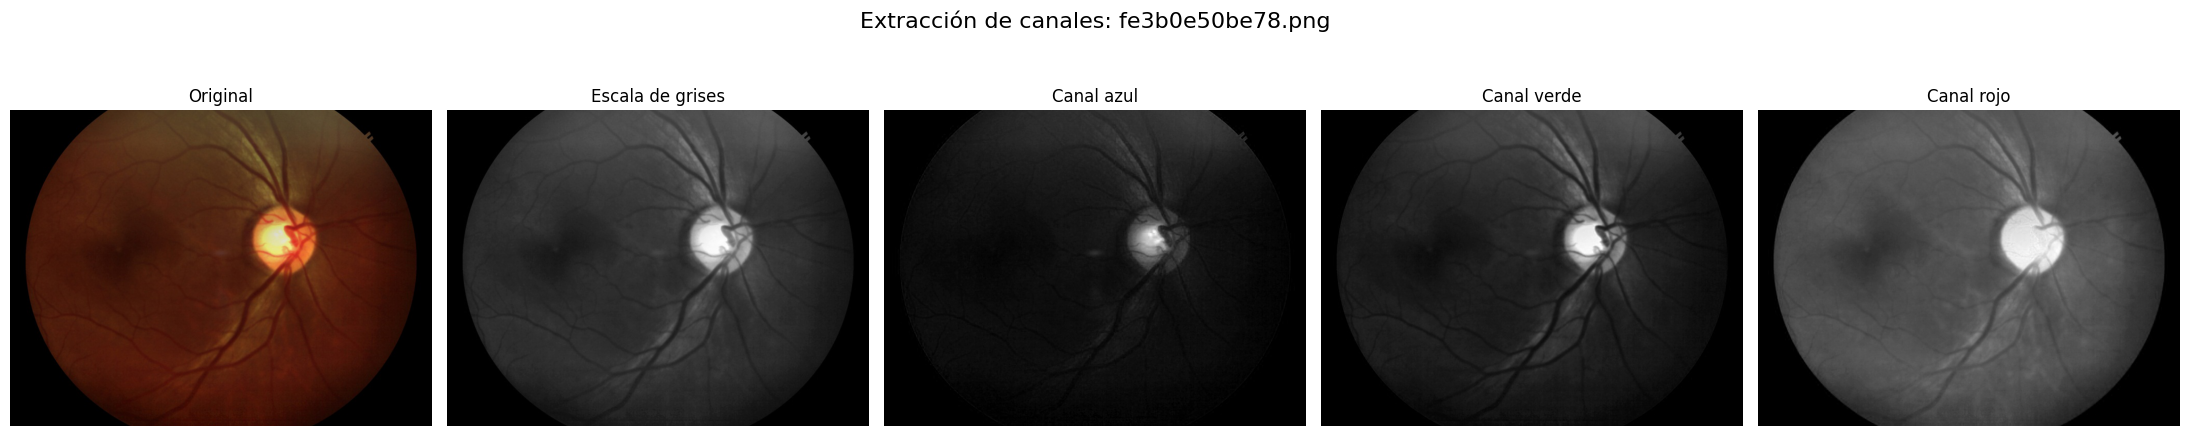

Procesada: fe3b0e50be78.png


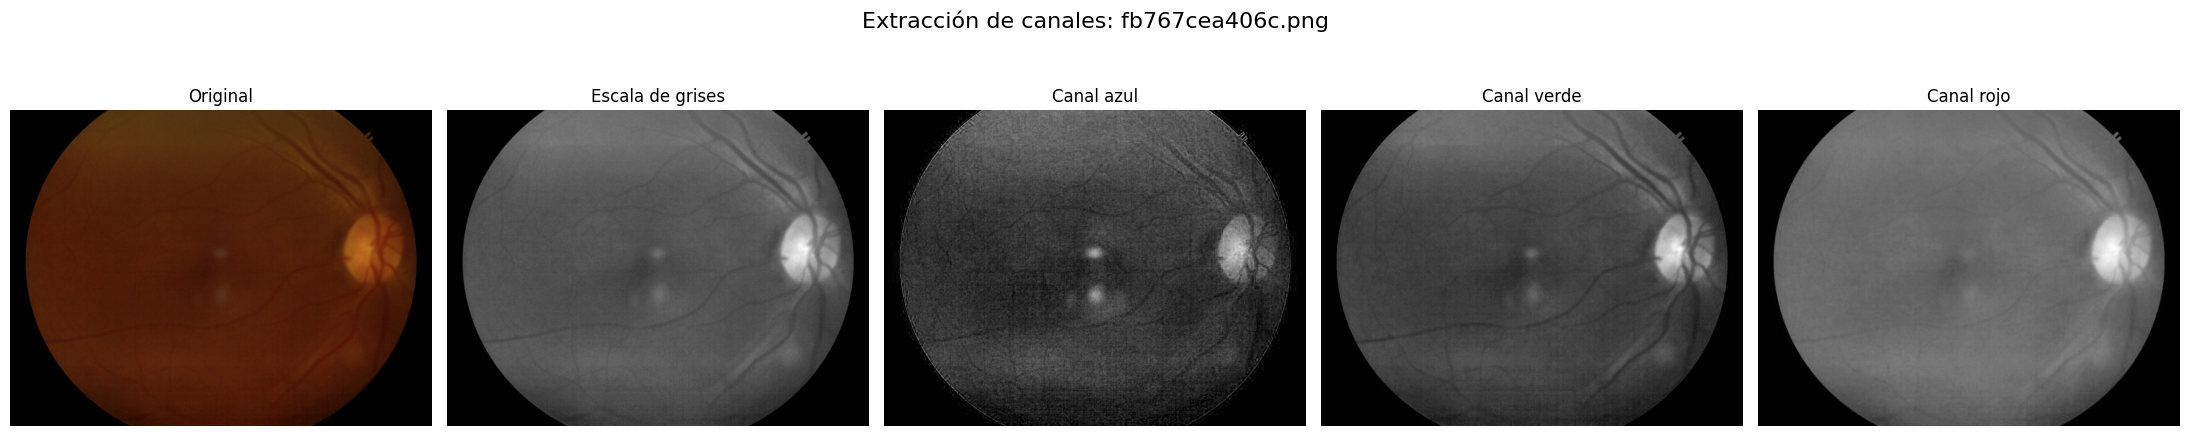

Procesada: fb767cea406c.png


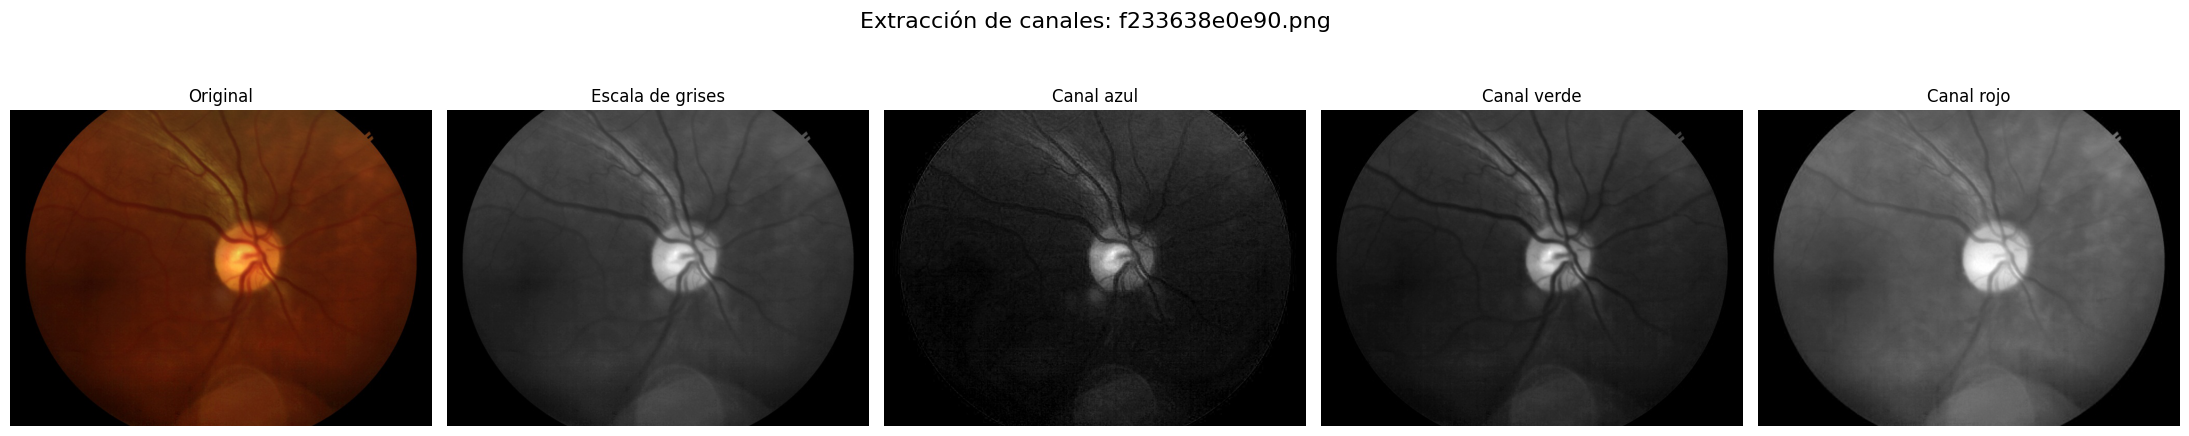

Procesada: f233638e0e90.png
Procesamiento completado.


In [9]:
formatos_validos = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff') #Extensiones de archivos que el programa va a aceptar como imágenes

for archivo_imagen in os.listdir(carpeta_imagenes): #Recorre todos los archivos dentro de la carpeta de imágenes
    if archivo_imagen.lower().endswith(formatos_validos): #Verifica si el archivo termina con alguna extensión válida
        ruta_imagen = os.path.join(carpeta_imagenes, archivo_imagen) #Construye la ruta completa de la imagen

        # Leer imagen en formato BGR
        imagen_bgr = cv2.imread(ruta_imagen)

        # Validar lectura
        if imagen_bgr is None: #Si la imagen no se pudo leer
            print(f'No se pudo leer la imagen: {archivo_imagen}')
            continue

        # Convertir a RGB para visualizar correctamente con matplotlib
        imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

        # Convertir a escala de grises
        imagen_gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)

        # Extraer canales BGR
        canal_azul = imagen_bgr[:, :, 0] #Posición
        canal_verde = imagen_bgr[:, :, 1]
        canal_rojo = imagen_bgr[:, :, 2]

        # Nombre base del archivo
        nombre_base = os.path.splitext(archivo_imagen)[0]

        # Guardar imágenes por separado
        cv2.imwrite(os.path.join(carpeta_gris, f'{nombre_base}_gris.png'), imagen_gris)
        cv2.imwrite(os.path.join(carpeta_azul, f'{nombre_base}_azul.png'), canal_azul)
        cv2.imwrite(os.path.join(carpeta_verde, f'{nombre_base}_verde.png'), canal_verde)
        cv2.imwrite(os.path.join(carpeta_rojo, f'{nombre_base}_rojo.png'), canal_rojo)

        # Crear subplots
        fig, axes = plt.subplots(1, 5, figsize=(22, 5))
        fig.suptitle(f'Extracción de canales: {archivo_imagen}', fontsize=16)

        axes[0].imshow(imagen_rgb)
        axes[0].set_title('Original')
        axes[0].axis('off')

        axes[1].imshow(imagen_gris, cmap='gray')
        axes[1].set_title('Escala de grises')
        axes[1].axis('off')

        axes[2].imshow(canal_azul, cmap='gray')
        axes[2].set_title('Canal azul')
        axes[2].axis('off')

        axes[3].imshow(canal_verde, cmap='gray')
        axes[3].set_title('Canal verde')
        axes[3].axis('off')

        axes[4].imshow(canal_rojo, cmap='gray')
        axes[4].set_title('Canal rojo')
        axes[4].axis('off')

        plt.tight_layout()

        # Guardar comparativa
        ruta_comparativa = os.path.join(carpeta_comparativas, f'{nombre_base}_comparativa.png')
        plt.savefig(ruta_comparativa, bbox_inches='tight', dpi=300)

        # Mostrar la figura
        plt.show()
        plt.close(fig)

        print(f'Procesada: {archivo_imagen}')

print('Procesamiento completado.')

Estos códigos permiten automatizar el procesamiento de imágenes digitales mediante la organización de carpetas y la extracción de información visual relevante. Se establece una estructura ordenada de almacenamiento que facilita la clasificación de resultados, de tal manera que no solo optimiza el manejo de múltiples imágenes, sino que también permite analizar la contribución de cada canal de color en la composición de una imagen. 